In [5]:
print("AI-Powered Sales Intelligence Project")
print("Python is working successfully!")

AI-Powered Sales Intelligence Project
Python is working successfully!


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sklearn
import xgboost
import statsmodels
import nltk
import spacy
import streamlit

print("All libraries are working successfully!")

All libraries are working successfully!


In [7]:
import pandas as pd

df = pd.read_csv("../data/train.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 9800
Columns: 18


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [8]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape:
(9800, 18)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64

In [9]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [10]:
df["Postal Code"] = df["Postal Code"].fillna(0)

print("Missing values after cleaning:")
print(df.isnull().sum().sum())

Missing values after cleaning:
0


In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [12]:
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")

print(df[["Order Date", "Ship Date"]].dtypes)

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


In [13]:
total_sales = df["Sales"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()

print("Total Sales:", round(total_sales, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)

Total Sales: 2261536.78
Total Orders: 4922
Total Customers: 793


In [14]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


In [15]:
average_order_value = df["Sales"].sum() / df["Order ID"].nunique()

print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 459.48


In [16]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [17]:
import matplotlib.pyplot as plt

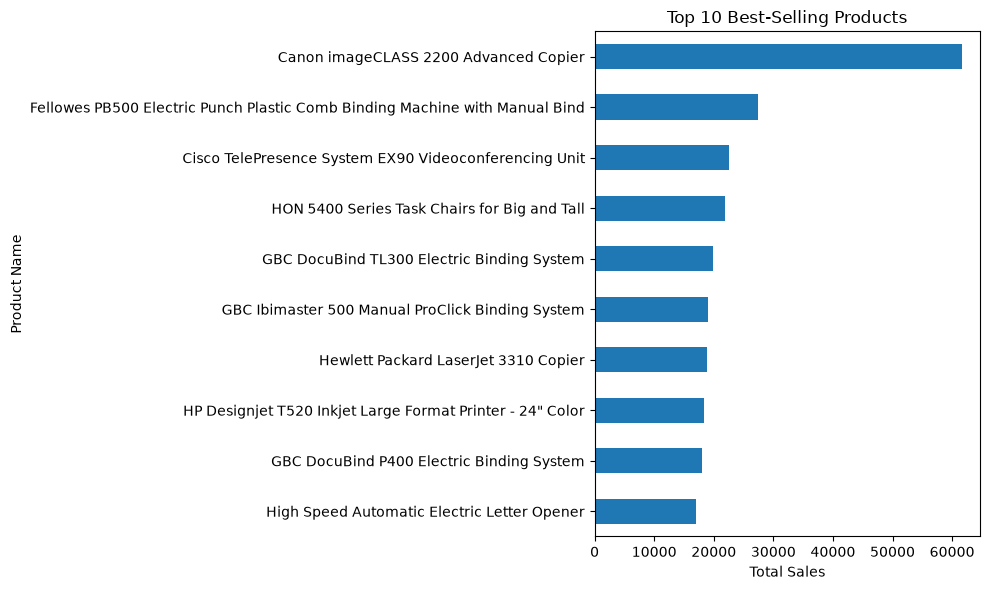

In [18]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")

plt.tight_layout()
plt.show()

In [19]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


In [20]:
monthly_sales = (
    df.set_index("Order Date")
    .resample("ME")["Sales"]
    .sum()
)

print(monthly_sales)

Order Date
2015-01-31    19546.1630
2015-02-28    11678.9940
2015-03-31     6716.0440
2015-04-30    12455.4820
2015-05-31    15165.0510
2015-06-30    11884.1690
2015-07-31    10075.7400
2015-08-31    26797.7630
2015-09-30    17158.9320
2015-10-31    10112.6410
2015-11-30    18349.7640
2015-12-31    17045.8427
2016-01-31    17701.6864
2016-02-29    13018.3150
2016-03-31    12207.4066
2016-04-30    11963.6960
2016-05-31    10483.4820
2016-06-30    13026.6682
2016-07-31    10706.7200
2016-08-31    22782.5770
2016-09-30    16484.9010
2016-10-31    12293.0380
2016-11-30    12139.0395
2016-12-31     9761.3330
2017-01-31    26342.5410
2017-02-28    42967.9150
2017-03-31    25982.2870
2017-04-30    19472.1640
2017-05-31    22649.3888
2017-06-30    14050.1430
2017-07-31    16501.0070
2017-08-31    24156.3226
2017-09-30     9789.6620
2017-10-31    22599.7820
2017-11-30    20378.2400
2017-12-31    21365.1485
2018-01-31    27367.5920
2018-02-28    36285.9360
2018-03-31    26882.9530
2018-04-30    

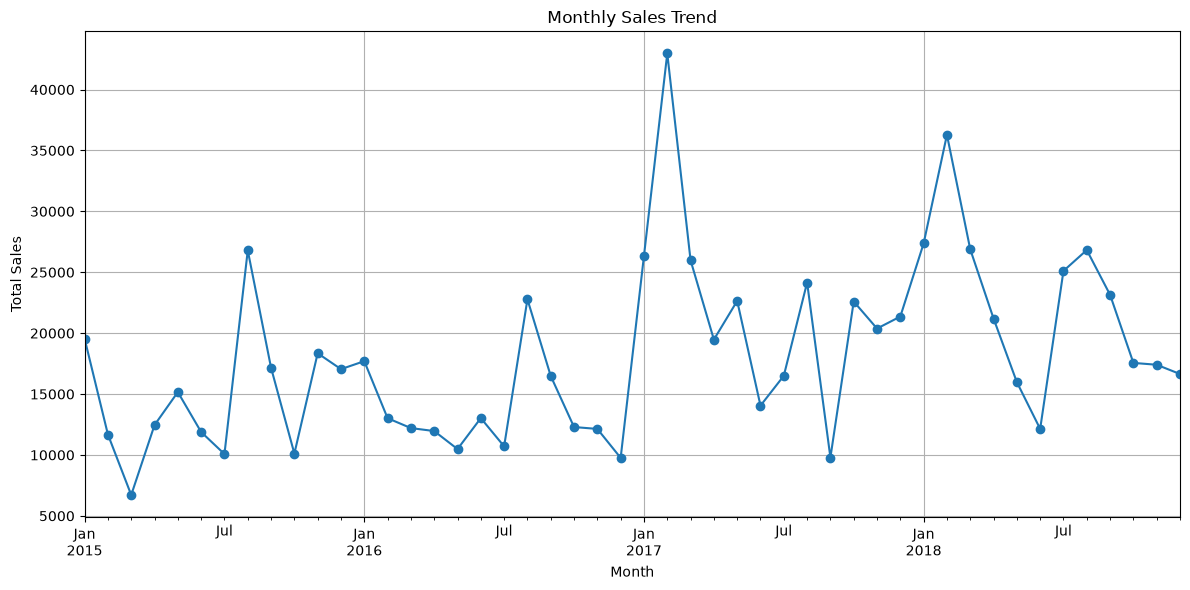

In [21]:
plt.figure(figsize=(12, 6))

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
forecast_df = monthly_sales.reset_index()

forecast_df.columns = ["Date", "Sales"]

forecast_df.head()

,Date,Sales
0,2015-01-31,19546.163
1,2015-02-28,11678.994
2,2015-03-31,6716.044
3,2015-04-30,12455.482
4,2015-05-31,15165.051


In [23]:
forecast_df["Year"] = forecast_df["Date"].dt.year
forecast_df["Month"] = forecast_df["Date"].dt.month
forecast_df["Month_Number"] = range(1, len(forecast_df) + 1)

forecast_df.head()

,Date,Sales,Year,Month,Month_Number
0,2015-01-31,19546.163,2015,1,1
1,2015-02-28,11678.994,2015,2,2
2,2015-03-31,6716.044,2015,3,3
3,2015-04-30,12455.482,2015,4,4
4,2015-05-31,15165.051,2015,5,5


In [24]:
train_size = int(len(forecast_df) * 0.8)

train_data = forecast_df.iloc[:train_size]
test_data = forecast_df.iloc[train_size:]

print("Training data:", len(train_data))
print("Testing data:", len(test_data))

Training data: 38
Testing data: 10


In [25]:
from sklearn.ensemble import RandomForestRegressor

# Features
X_train = train_data[["Year", "Month", "Month_Number"]]
y_train = train_data["Sales"]

X_test = test_data[["Year", "Month", "Month_Number"]]
y_test = test_data["Sales"]

# Create model
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

print("Forecasting model trained successfully!")

Forecasting model trained successfully!


In [26]:
# Predict sales for test data
y_pred = model.predict(X_test)

print("Predicted Sales:")
print(y_pred)

Predicted Sales:
[27209.0271535 23134.1478065 22463.004081  21447.6847795 21400.3284345
 22560.446386  21332.7313125 22716.9322685 23638.252438  23691.210673 ]


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))

Mean Absolute Error (MAE): 4627.33
Root Mean Squared Error (RMSE): 5318.24


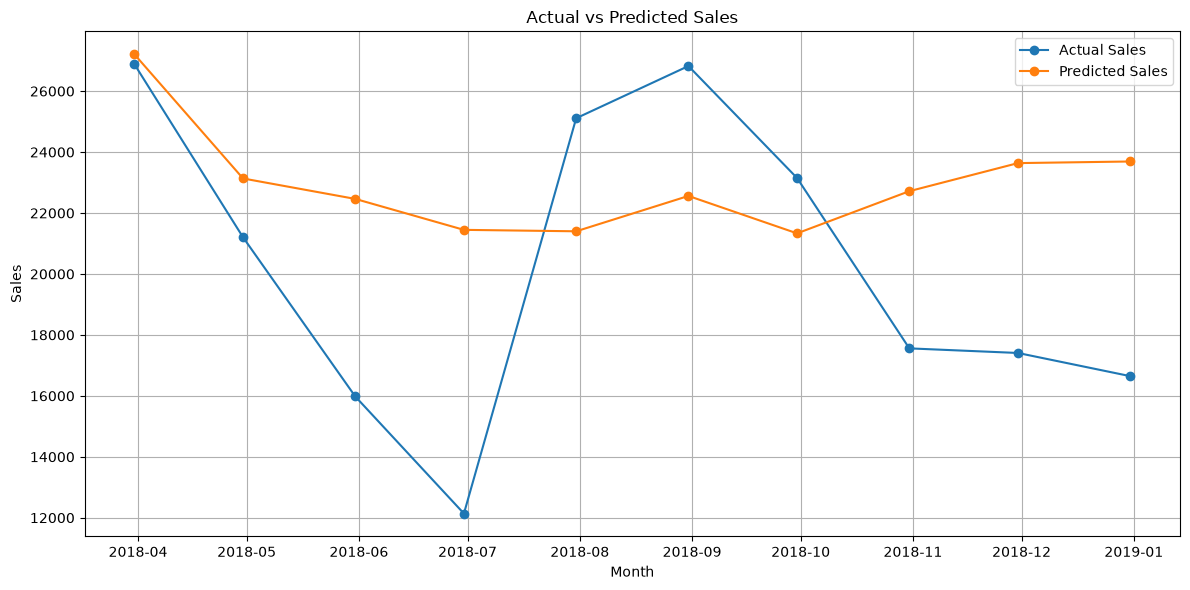

In [28]:
# Actual vs Predicted Sales

plt.figure(figsize=(12, 6))

plt.plot(
    test_data["Date"],
    y_test,
    marker="o",
    label="Actual Sales"
)

plt.plot(
    test_data["Date"],
    y_pred,
    marker="o",
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [29]:
# Create future dates for the next 6 months

last_date = forecast_df["Date"].max()

future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=6,
    freq="ME"
)

future_df = pd.DataFrame({
    "Date": future_dates
})

future_df["Year"] = future_df["Date"].dt.year
future_df["Month"] = future_df["Date"].dt.month
future_df["Month_Number"] = range(
    len(forecast_df) + 1,
    len(forecast_df) + 7
)

future_df

,Date,Year,Month,Month_Number
0,2019-01-31,2019,1,49
1,2019-02-28,2019,2,50
2,2019-03-31,2019,3,51
3,2019-04-30,2019,4,52
4,2019-05-31,2019,5,53
5,2019-06-30,2019,6,54


In [30]:
# Predict sales for the next 6 months

future_X = future_df[["Year", "Month", "Month_Number"]]

future_predictions = model.predict(future_X)

future_df["Predicted_Sales"] = future_predictions

future_df

,Date,Year,Month,Month_Number,Predicted_Sales
0,2019-01-31,2019,1,49,30057.746319
1,2019-02-28,2019,2,50,34339.104224
2,2019-03-31,2019,3,51,27209.027153
3,2019-04-30,2019,4,52,23134.147807
4,2019-05-31,2019,5,53,22463.004081
5,2019-06-30,2019,6,54,21447.684780


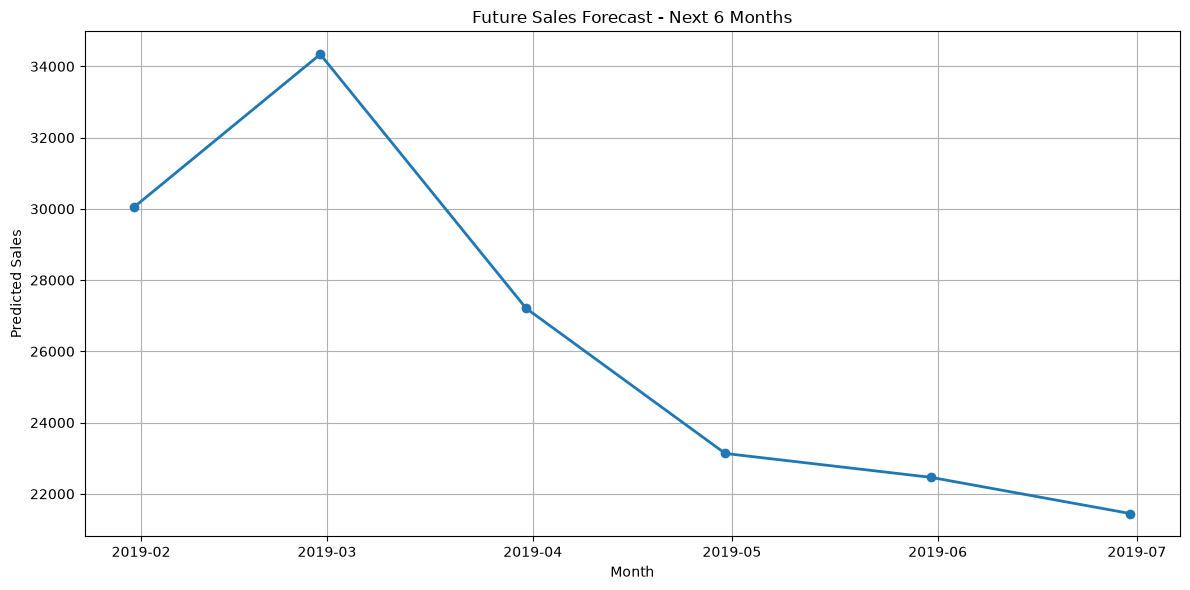

In [31]:
# Future Sales Forecast

plt.figure(figsize=(12, 6))

plt.plot(
    future_df["Date"],
    future_df["Predicted_Sales"],
    marker="o",
    linewidth=2
)

plt.title("Future Sales Forecast - Next 6 Months")
plt.xlabel("Month")
plt.ylabel("Predicted Sales")
plt.grid(True)

plt.tight_layout()
plt.show()

In [32]:
future_df

,Date,Year,Month,Month_Number,Predicted_Sales
0,2019-01-31,2019,1,49,30057.746319
1,2019-02-28,2019,2,50,34339.104224
2,2019-03-31,2019,3,51,27209.027153
3,2019-04-30,2019,4,52,23134.147807
4,2019-05-31,2019,5,53,22463.004081
5,2019-06-30,2019,6,54,21447.684780


In [33]:
# Create lag features for forecasting

model_df = forecast_df.copy()

# Previous month's sales
model_df["Sales_Lag1"] = model_df["Sales"].shift(1)

# Sales from 2 months ago
model_df["Sales_Lag2"] = model_df["Sales"].shift(2)

# 3-month rolling average
model_df["Rolling_Mean_3"] = (
    model_df["Sales"]
    .rolling(window=3)
    .mean()
)

model_df.head()

,Date,Sales,Year,Month,Month_Number,Sales_Lag1,Sales_Lag2,Rolling_Mean_3
0,2015-01-31,19546.163,2015,1,1,NaN,NaN,NaN
1,2015-02-28,11678.994,2015,2,2,19546.163,NaN,NaN
2,2015-03-31,6716.044,2015,3,3,11678.994,19546.163,12647.067000
3,2015-04-30,12455.482,2015,4,4,6716.044,11678.994,10283.506667
4,2015-05-31,15165.051,2015,5,5,12455.482,6716.044,11445.525667


In [34]:
# Remove rows with missing lag/rolling values

model_df = model_df.dropna().reset_index(drop=True)

print("Rows after removing missing values:", len(model_df))
model_df.head()

Rows after removing missing values: 46


,Date,Sales,Year,Month,Month_Number,Sales_Lag1,Sales_Lag2,Rolling_Mean_3
0,2015-03-31,6716.044,2015,3,3,11678.994,19546.163,12647.067000
1,2015-04-30,12455.482,2015,4,4,6716.044,11678.994,10283.506667
2,2015-05-31,15165.051,2015,5,5,12455.482,6716.044,11445.525667
3,2015-06-30,11884.169,2015,6,6,15165.051,12455.482,13168.234000
4,2015-07-31,10075.740,2015,7,7,11884.169,15165.051,12374.986667


In [35]:
# Split improved dataset into training and testing data

train_size = int(len(model_df) * 0.8)

improved_train = model_df.iloc[:train_size]
improved_test = model_df.iloc[train_size:]

print("Training data:", len(improved_train))
print("Testing data:", len(improved_test))

Training data: 36
Testing data: 10


In [36]:
# Create improved forecasting dataset

improved_df = forecast_df.copy()

# Create lag features
improved_df["Sales_Lag1"] = improved_df["Sales"].shift(1)
improved_df["Sales_Lag2"] = improved_df["Sales"].shift(2)
improved_df["Rolling_Mean_3"] = improved_df["Sales"].rolling(3).mean()

# Remove missing values created by lag features
improved_df = improved_df.dropna().reset_index(drop=True)

# Features used by the model
features = [
    "Month_Number",
    "Year",
    "Month",
    "Sales_Lag1",
    "Sales_Lag2",
    "Rolling_Mean_3"
]

# Split into training and testing data
split_index = int(len(improved_df) * 0.8)

improved_train = improved_df.iloc[:split_index]
improved_test = improved_df.iloc[split_index:]

print("Improved dataset created successfully!")
print("Training data:", improved_train.shape)
print("Testing data:", improved_test.shape)

Improved dataset created successfully!
Training data: (36, 8)
Testing data: (10, 8)


In [37]:
from sklearn.ensemble import RandomForestRegressor

# Select improved features
features = [
    "Year",
    "Month",
    "Month_Number",
    "Sales_Lag1",
    "Sales_Lag2",
    "Rolling_Mean_3"
]

# Training data
X_train_improved = improved_train[features]
y_train_improved = improved_train["Sales"]

# Testing data
X_test_improved = improved_test[features]
y_test_improved = improved_test["Sales"]

# Create improved Random Forest model
improved_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train the model
improved_model.fit(X_train_improved, y_train_improved)

print("Improved forecasting model trained successfully!")

Improved forecasting model trained successfully!


In [38]:
print("Features used during model training:")
print(improved_model.feature_names_in_)

Features used during model training:
['Year' 'Month' 'Month_Number' 'Sales_Lag1' 'Sales_Lag2' 'Rolling_Mean_3']


In [39]:
# Predict sales for improved test data

y_pred_improved = improved_model.predict(X_test_improved)

print("Improved Model Predictions:")
print(y_pred_improved)

Improved Model Predictions:
[30365.75459   28522.8405555 23943.0244115 18668.376925  19561.4738905
 23411.0831445 27946.2688695 22136.9588005 21568.4401295 17476.3222155]


In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate improved model MAE
mae_improved = mean_absolute_error(
    y_test_improved,
    y_pred_improved
)

# Calculate improved model RMSE
rmse_improved = np.sqrt(
    mean_squared_error(
        y_test_improved,
        y_pred_improved
    )
)

print("Improved Model MAE:", round(mae_improved, 2))
print("Improved Model RMSE:", round(rmse_improved, 2))

Improved Model MAE: 4862.42
Improved Model RMSE: 5255.35


In [41]:
# Customer Segmentation - RFM Analysis

import pandas as pd
import numpy as np

# Reference date
reference_date = df["Order Date"].max() + pd.Timedelta(days=1)

# Create RFM table
rfm = df.groupby("Customer ID").agg({
    "Order Date": lambda x: (reference_date - x.max()).days,
    "Order ID": "nunique",
    "Sales": "sum"
})

# Rename columns
rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
AA-10315,649.0,5,5563.560
AA-10375,30.0,9,1056.390
AA-10480,1347.0,4,1790.512
AA-10645,215.0,6,5086.935
AB-10015,427.0,3,886.156


In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"],
    index=rfm.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
Customer ID,,,
AA-10315,0.777912,-0.478124,1.035383
AA-10375,-0.979522,1.106629,-0.685557
AA-10480,2.759639,-0.874312,-0.405253
AA-10645,-0.454280,-0.081935,0.853397
AB-10015,0.147620,-1.270500,-0.750556


In [43]:
print("RFM shape:", rfm.shape)
print("Scaled RFM shape:", rfm_scaled.shape)

print("\nRFM data types:")
print(rfm.dtypes)

print("\nMissing values:")
print(rfm.isnull().sum())

RFM shape: (793, 3)
Scaled RFM shape: (793, 3)

RFM data types:
Recency      float64
Frequency      int64
Monetary     float64
dtype: object

Missing values:
Recency      57
Frequency     0
Monetary      0
dtype: int64


In [44]:
rfm["Recency"] = rfm["Recency"].fillna(rfm["Recency"].median())

print("Missing values after fixing:")
print(rfm.isnull().sum())

Missing values after fixing:
Recency      0
Frequency    0
Monetary     0
dtype: int64


In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm[["Recency", "Frequency", "Monetary"]])

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"],
    index=rfm.index
)

print("Scaling completed successfully!")

Scaling completed successfully!


In [46]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("Customer segmentation completed successfully!")
print(rfm.head())

Customer segmentation completed successfully!
             Recency  Frequency  Monetary  Cluster
Customer ID                                       
AA-10315       649.0          5  5563.560        2
AA-10375        30.0          9  1056.390        3
AA-10480      1347.0          4  1790.512        2
AA-10645       215.0          6  5086.935        3
AB-10015       427.0          3   886.156        0


In [47]:
cluster_summary = rfm.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
}).round(2)

print(cluster_summary)

         Recency  Frequency  Monetary
Cluster                              
0         257.79       4.36   1620.94
1         258.22       8.25   9161.89
2         987.86       5.39   2164.83
3         198.30       8.55   3133.53


In [48]:
cluster_names = {
    0: "Regular / Low-Value",
    1: "High-Value",
    2: "At-Risk",
    3: "Loyal / Frequent"
}

rfm["Customer_Segment"] = rfm["Cluster"].map(cluster_names)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Customer_Segment
Customer ID,,,,,
AA-10315,649.0,5,5563.560,2,At-Risk
AA-10375,30.0,9,1056.390,3,Loyal / Frequent
AA-10480,1347.0,4,1790.512,2,At-Risk
AA-10645,215.0,6,5086.935,3,Loyal / Frequent
AB-10015,427.0,3,886.156,0,Regular / Low-Value


In [49]:
segment_counts = rfm["Customer_Segment"].value_counts()

print(segment_counts)

Customer_Segment
Regular / Low-Value    333
Loyal / Frequent       251
At-Risk                140
High-Value              69
Name: count, dtype: int64


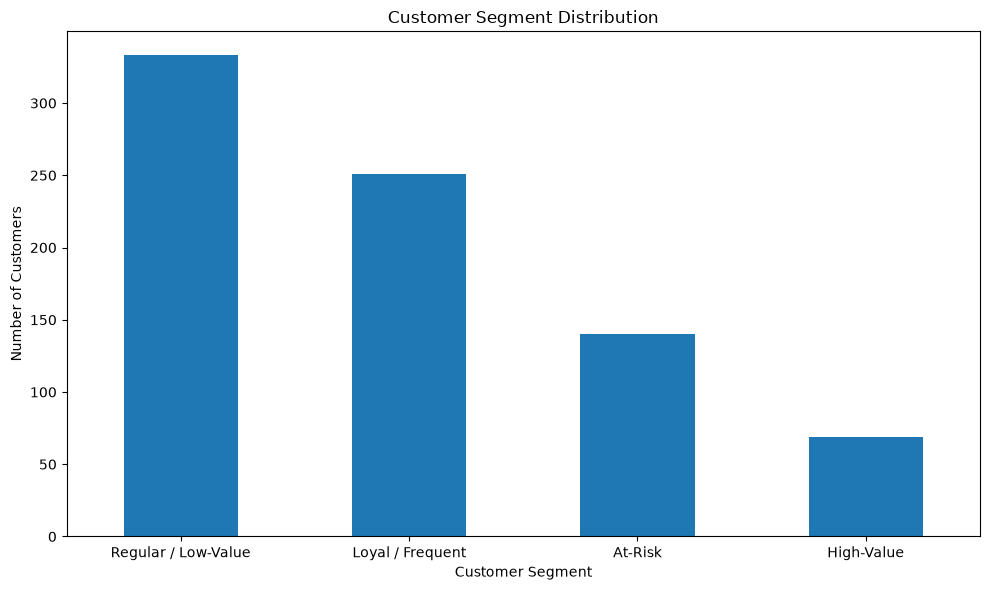

In [50]:
plt.figure(figsize=(10, 6))

segment_counts.plot(kind="bar")

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [51]:
segment_sales = rfm.groupby("Customer_Segment")["Monetary"].sum().sort_values(ascending=False)

print("Sales by Customer Segment:")
print(segment_sales.round(2))

Sales by Customer Segment:
Customer_Segment
Loyal / Frequent       786517.13
High-Value             632170.62
Regular / Low-Value    539772.71
At-Risk                303076.32
Name: Monetary, dtype: float64


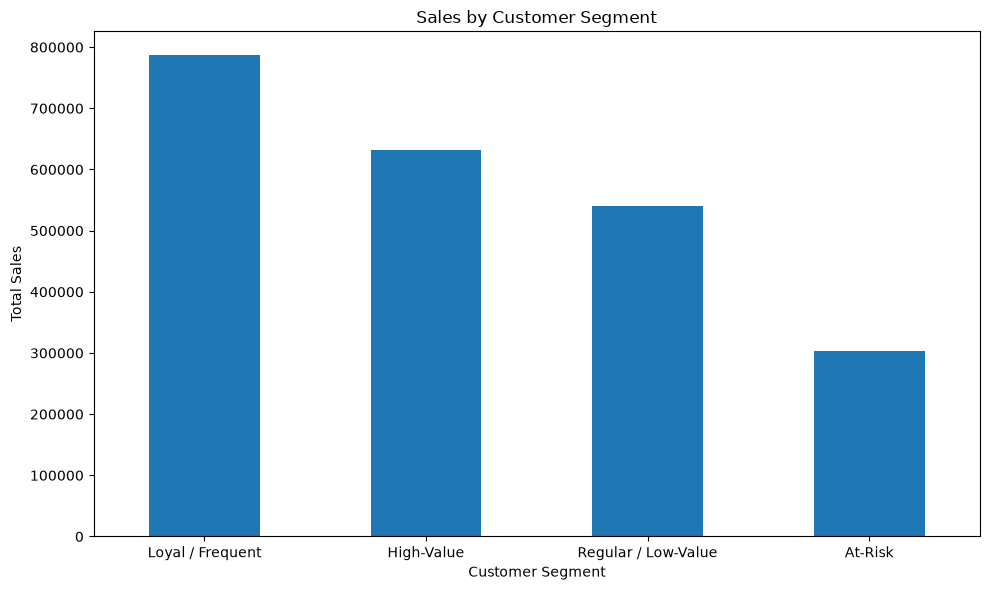

In [52]:
plt.figure(figsize=(10, 6))

segment_sales.plot(kind="bar")

plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [53]:
reviews_df = pd.read_csv("../DATA/Dataset-SA.csv")

print("Reviews dataset loaded successfully!")
print("Shape:", reviews_df.shape)

Reviews dataset loaded successfully!
Shape: (205052, 6)


In [54]:
print(reviews_df.columns)

Index(['product_name', 'product_price', 'Rate', 'Review', 'Summary',
       'Sentiment'],
      dtype='str')


In [55]:
print(reviews_df.head())

                                        product_name product_price Rate  \
0  Candes 12 L Room/Personal Air Cooler??????(Whi...          3999    5   
1  Candes 12 L Room/Personal Air Cooler??????(Whi...          3999    5   
2  Candes 12 L Room/Personal Air Cooler??????(Whi...          3999    3   
3  Candes 12 L Room/Personal Air Cooler??????(Whi...          3999    1   
4  Candes 12 L Room/Personal Air Cooler??????(Whi...          3999    3   

            Review                                            Summary  \
0           super!  great cooler excellent air flow and for this p...   
1          awesome              best budget 2 fit cooler nice cooling   
2             fair  the quality is good but the power of air is de...   
3  useless product                  very bad product its a only a fan   
4             fair                                      ok ok product   

  Sentiment  
0  positive  
1  positive  
2  positive  
3  negative  
4   neutral  


In [56]:
print(reviews_df.isnull().sum())

product_name         0
product_price        0
Rate                 0
Review           24664
Summary             11
Sentiment            0
dtype: int64


In [57]:
reviews_df["Review"] = reviews_df["Review"].fillna("")
reviews_df["Summary"] = reviews_df["Summary"].fillna("")

print(reviews_df.isnull().sum())

product_name     0
product_price    0
Rate             0
Review           0
Summary          0
Sentiment        0
dtype: int64


In [58]:
reviews_df["Review_Text"] = (
    reviews_df["Review"].astype(str) + " " +
    reviews_df["Summary"].astype(str)
)

print(reviews_df[["Review", "Summary", "Review_Text"]].head())

            Review                                            Summary  \
0           super!  great cooler excellent air flow and for this p...   
1          awesome              best budget 2 fit cooler nice cooling   
2             fair  the quality is good but the power of air is de...   
3  useless product                  very bad product its a only a fan   
4             fair                                      ok ok product   

                                         Review_Text  
0  super! great cooler excellent air flow and for...  
1      awesome best budget 2 fit cooler nice cooling  
2  fair the quality is good but the power of air ...  
3  useless product very bad product its a only a fan  
4                                 fair ok ok product  


In [59]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

reviews_df["Cleaned_Review"] = reviews_df["Review_Text"].apply(clean_text)

print(reviews_df[["Review_Text", "Cleaned_Review"]].head())

                                         Review_Text  \
0  super! great cooler excellent air flow and for...   
1      awesome best budget 2 fit cooler nice cooling   
2  fair the quality is good but the power of air ...   
3  useless product very bad product its a only a fan   
4                                 fair ok ok product   

                                      Cleaned_Review  
0  super great cooler excellent air flow and for ...  
1        awesome best budget fit cooler nice cooling  
2  fair the quality is good but the power of air ...  
3  useless product very bad product its a only a fan  
4                                 fair ok ok product  


In [60]:
sentiment_counts = reviews_df["Sentiment"].value_counts()

print(sentiment_counts)

Sentiment
positive    166581
negative     28232
neutral      10239
Name: count, dtype: int64


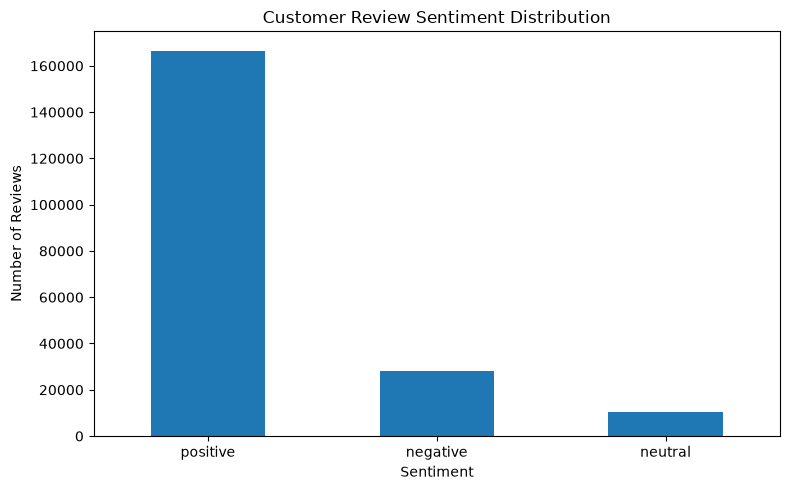

In [61]:
plt.figure(figsize=(8, 5))

sentiment_counts.plot(kind="bar")

plt.title("Customer Review Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [62]:
from sklearn.model_selection import train_test_split

X = reviews_df["Cleaned_Review"]
y = reviews_df["Sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 164041
Testing data: 41011


In [63]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (164041, 5000)
Testing TF-IDF shape: (41011, 5000)


In [64]:
from sklearn.linear_model import LogisticRegression

sentiment_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

sentiment_model.fit(X_train_tfidf, y_train)

print("Sentiment model trained successfully!")

Sentiment model trained successfully!


In [65]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = sentiment_model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 93.02 %

Classification Report:
              precision    recall  f1-score   support

    negative       0.85      0.82      0.83      5646
     neutral       0.74      0.40      0.52      2048
    positive       0.95      0.98      0.97     33317

    accuracy                           0.93     41011
   macro avg       0.85      0.73      0.77     41011
weighted avg       0.92      0.93      0.92     41011



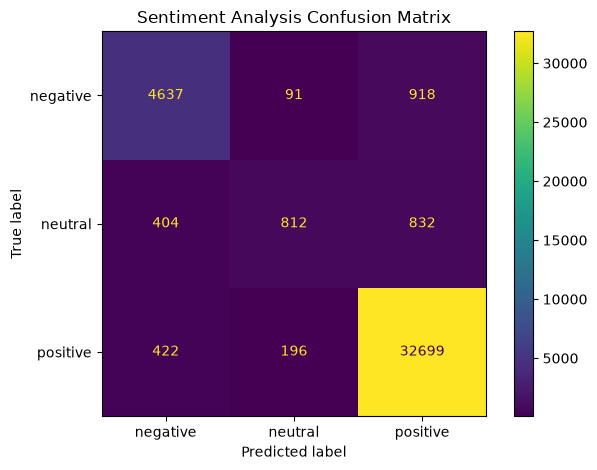

In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sentiment_model.classes_
)

disp.plot()
plt.title("Sentiment Analysis Confusion Matrix")
plt.tight_layout()
plt.show()

In [67]:
sample_reviews = [
    "This product is amazing and works perfectly",
    "Very bad product, completely useless",
    "The product is okay, nothing special"
]

sample_tfidf = tfidf.transform(sample_reviews)

sample_predictions = sentiment_model.predict(sample_tfidf)

for review, sentiment in zip(sample_reviews, sample_predictions):
    print("Review:", review)
    print("Predicted Sentiment:", sentiment)
    print()

Review: This product is amazing and works perfectly
Predicted Sentiment: positive

Review: Very bad product, completely useless
Predicted Sentiment: negative

Review: The product is okay, nothing special
Predicted Sentiment: positive



In [68]:
import pandas as pd

# Load customer reviews dataset
reviews_df = pd.read_csv("../DATA/Dataset-SA.csv")

# Convert rating to numeric
reviews_df["Rate"] = pd.to_numeric(reviews_df["Rate"], errors="coerce")

# Fill missing review text
reviews_df["Review"] = reviews_df["Review"].fillna("")
reviews_df["Summary"] = reviews_df["Summary"].fillna("")

# Create combined review text
reviews_df["Review_Text"] = (
    reviews_df["Review"].astype(str) + " " +
    reviews_df["Summary"].astype(str)
)

print("Reviews dataset loaded successfully!")
print("Shape:", reviews_df.shape)

Reviews dataset loaded successfully!
Shape: (205052, 7)


In [69]:
reviews_df["Rate"] = pd.to_numeric(reviews_df["Rate"], errors="coerce")

sentiment_summary = reviews_df.groupby("Sentiment").agg(
    Review_Count=("Review_Text", "count"),
    Average_Rating=("Rate", "mean")
).round(2)

print(sentiment_summary)

           Review_Count  Average_Rating
Sentiment                              
negative          28232            1.59
neutral           10239            3.30
positive         166581            4.60


In [64]:
reviews_df["Rate"] = pd.to_numeric(reviews_df["Rate"], errors="coerce")

print(reviews_df["Rate"].dtype)

float64


In [65]:
sentiment_summary = reviews_df.groupby("Sentiment").agg(
    Review_Count=("Review_Text", "count"),
    Average_Rating=("Rate", "mean")
).round(2)

print(sentiment_summary)

           Review_Count  Average_Rating
Sentiment                              
negative          28232            1.59
neutral           10239            3.30
positive         166581            4.60


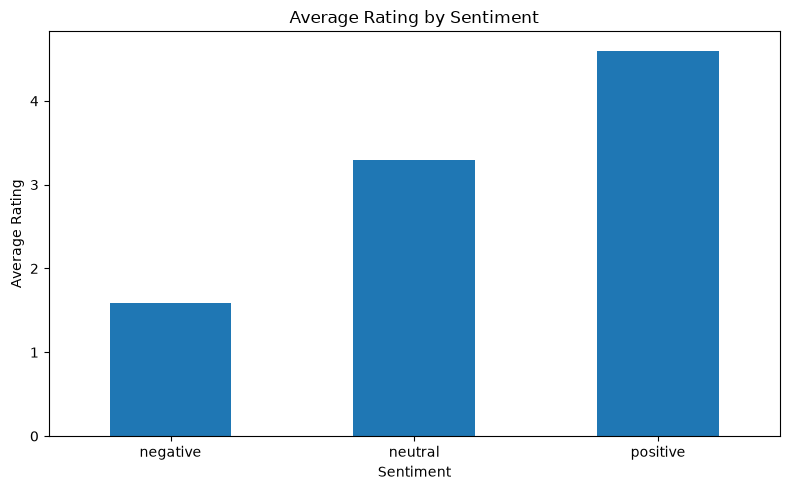

In [66]:
sentiment_summary["Average_Rating"].plot(kind="bar", figsize=(8, 5))

plt.title("Average Rating by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [67]:
# Step 7.1 - Business Insights Summary

print("========== AI BUSINESS INSIGHTS ==========\n")

print("📊 SALES INSIGHTS")
print("Total Sales: ₹", round(total_sales, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value: ₹", round(average_order_value, 2))

print("\n👥 CUSTOMER SEGMENT INSIGHTS")
print("Top Customer Segment by Sales:")
print(segment_sales.idxmax())
print("Sales Contribution: ₹", round(segment_sales.max(), 2))

print("\n⚠️ AT-RISK CUSTOMERS")
print("Number of At-Risk Customers:",
      segment_counts.get("At-Risk", 0))

print("\n💬 SENTIMENT INSIGHTS")
print("Most Common Sentiment:")
print(sentiment_counts.idxmax())

print("Average Rating of Negative Reviews:",
      round(sentiment_summary.loc["negative", "Average_Rating"], 2))

print("\n🔮 FORECASTING")
print("Next 6 Months Forecast:")
print(future_df[["Date", "Predicted_Sales"]])

========== AI BUSINESS INSIGHTS ==========

📊 SALES INSIGHTS
Total Sales: ₹ 2261536.78
Total Orders: 4922
Total Customers: 793
Average Order Value: ₹ 459.48

👥 CUSTOMER SEGMENT INSIGHTS
Top Customer Segment by Sales:
Loyal / Frequent
Sales Contribution: ₹ 786517.13

⚠️ AT-RISK CUSTOMERS
Number of At-Risk Customers: 140

💬 SENTIMENT INSIGHTS
Most Common Sentiment:
positive
Average Rating of Negative Reviews: 1.59

🔮 FORECASTING
Next 6 Months Forecast:
        Date  Predicted_Sales
0 2019-01-31     30057.746319
1 2019-02-28     34339.104224
2 2019-03-31     27209.027153
3 2019-04-30     23134.147807
4 2019-05-31     22463.004081
5 2019-06-30     21447.684780


In [68]:
# Step 7.2 - AI Business Recommendations

print("========== BUSINESS RECOMMENDATIONS ==========\n")

# Recommendation 1
print("1. CUSTOMER RETENTION")
print(f"There are {segment_counts.get('At-Risk', 0)} At-Risk customers.")
print("Recommendation: Launch targeted retention campaigns, special offers, and personalized communication for At-Risk customers.")

# Recommendation 2
print("\n2. HIGH-VALUE CUSTOMERS")
print(f"The {segment_counts.get('High-Value', 0)} High-Value customers contribute ₹{segment_sales.get('High-Value', 0):,.2f} in sales.")
print("Recommendation: Focus on loyalty programs, premium offers, and personalized deals for High-Value customers.")

# Recommendation 3
print("\n3. LOYAL CUSTOMERS")
print(f"Loyal / Frequent customers contribute ₹{segment_sales.get('Loyal / Frequent', 0):,.2f} in sales.")
print("Recommendation: Strengthen customer loyalty through rewards, exclusive offers, and repeat-purchase campaigns.")

# Recommendation 4
print("\n4. CUSTOMER EXPERIENCE")
print(f"Negative reviews have an average rating of {sentiment_summary.loc['negative', 'Average_Rating']:.2f}.")
print("Recommendation: Identify common complaints in negative reviews and improve the areas causing customer dissatisfaction.")

# Recommendation 5
print("\n5. SALES FORECAST")
print("The forecasting model provides estimated sales for the next 6 months.")
print("Recommendation: Use the forecast to plan inventory, marketing campaigns, and business resources.")

========== BUSINESS RECOMMENDATIONS ==========

1. CUSTOMER RETENTION
There are 140 At-Risk customers.
Recommendation: Launch targeted retention campaigns, special offers, and personalized communication for At-Risk customers.

2. HIGH-VALUE CUSTOMERS
The 69 High-Value customers contribute ₹632,170.62 in sales.
Recommendation: Focus on loyalty programs, premium offers, and personalized deals for High-Value customers.

3. LOYAL CUSTOMERS
Loyal / Frequent customers contribute ₹786,517.13 in sales.
Recommendation: Strengthen customer loyalty through rewards, exclusive offers, and repeat-purchase campaigns.

4. CUSTOMER EXPERIENCE
Negative reviews have an average rating of 1.59.
Recommendation: Identify common complaints in negative reviews and improve the areas causing customer dissatisfaction.

5. SALES FORECAST
The forecasting model provides estimated sales for the next 6 months.
Recommendation: Use the forecast to plan inventory, marketing campaigns, and business resources.


In [69]:
# Step 7.3 - Dynamic AI Business Insights

insights = []

# Customer retention insight
at_risk = segment_counts.get("At-Risk", 0)

if at_risk > 100:
    insights.append(
        f"⚠️ {at_risk} customers are At-Risk. "
        "The business should prioritize customer retention campaigns."
    )
else:
    insights.append(
        f"✅ Only {at_risk} customers are At-Risk. "
        "Current customer retention appears relatively healthy."
    )

# High-value customer insight
high_value = segment_counts.get("High-Value", 0)
high_value_sales = segment_sales.get("High-Value", 0)

insights.append(
    f"💎 {high_value} High-Value customers contribute "
    f"₹{high_value_sales:,.2f} in sales. "
    "Personalized offers and loyalty benefits can help retain these customers."
)

# Loyal customer insight
loyal_sales = segment_sales.get("Loyal / Frequent", 0)

insights.append(
    f"👑 Loyal / Frequent customers contribute "
    f"₹{loyal_sales:,.2f} in sales. "
    "The business should strengthen loyalty and repeat purchases."
)

# Sentiment insight
negative_rating = sentiment_summary.loc["negative", "Average_Rating"]

if negative_rating < 2:
    insights.append(
        f"🚨 Negative reviews have an average rating of {negative_rating:.2f}. "
        "Customer complaints should be investigated to improve product and service quality."
    )

# Forecast insight
next_month_sales = future_df.iloc[0]["Predicted_Sales"]

insights.append(
    f"🔮 The next month's predicted sales are "
    f"₹{next_month_sales:,.2f}. "
    "This forecast can support inventory and marketing planning."
)

print("========== DYNAMIC AI BUSINESS INSIGHTS ==========\n")

for i, insight in enumerate(insights, 1):
    print(f"{i}. {insight}\n")

========== DYNAMIC AI BUSINESS INSIGHTS ==========

1. ⚠️ 140 customers are At-Risk. The business should prioritize customer retention campaigns.

2. 💎 69 High-Value customers contribute ₹632,170.62 in sales. Personalized offers and loyalty benefits can help retain these customers.

3. 👑 Loyal / Frequent customers contribute ₹786,517.13 in sales. The business should strengthen loyalty and repeat purchases.

4. 🚨 Negative reviews have an average rating of 1.59. Customer complaints should be investigated to improve product and service quality.

5. 🔮 The next month's predicted sales are ₹30,057.75. This forecast can support inventory and marketing planning.



In [70]:
# Step 7.4 - Structured AI Insights

ai_insights = {
    "Customer Retention": {
        "status": "Warning",
        "insight": f"{at_risk} customers are currently classified as At-Risk.",
        "recommendation": "Launch targeted retention campaigns and personalized offers."
    },

    "High-Value Customers": {
        "status": "Opportunity",
        "insight": f"{high_value} High-Value customers contribute ₹{high_value_sales:,.2f} in sales.",
        "recommendation": "Use premium offers and loyalty benefits to retain these customers."
    },

    "Loyal Customers": {
        "status": "Positive",
        "insight": f"Loyal / Frequent customers contribute ₹{loyal_sales:,.2f} in sales.",
        "recommendation": "Strengthen loyalty programs and encourage repeat purchases."
    },

    "Customer Experience": {
        "status": "Critical",
        "insight": f"Negative reviews have an average rating of {negative_rating:.2f}.",
        "recommendation": "Investigate common complaints and improve customer experience."
    },

    "Sales Forecast": {
        "status": "Forecast",
        "insight": f"Next month's predicted sales are ₹{next_month_sales:,.2f}.",
        "recommendation": "Use the forecast for inventory and marketing planning."
    }
}

print("========== AI INSIGHTS SUMMARY ==========\n")

for category, details in ai_insights.items():
    print(f"📌 {category}")
    print("Status:", details["status"])
    print("Insight:", details["insight"])
    print("Recommendation:", details["recommendation"])
    print()

========== AI INSIGHTS SUMMARY ==========

📌 Customer Retention
Status: Warning
Insight: 140 customers are currently classified as At-Risk.
Recommendation: Launch targeted retention campaigns and personalized offers.

📌 High-Value Customers
Status: Opportunity
Insight: 69 High-Value customers contribute ₹632,170.62 in sales.
Recommendation: Use premium offers and loyalty benefits to retain these customers.

📌 Loyal Customers
Status: Positive
Insight: Loyal / Frequent customers contribute ₹786,517.13 in sales.
Recommendation: Strengthen loyalty programs and encourage repeat purchases.

📌 Customer Experience
Status: Critical
Insight: Negative reviews have an average rating of 1.59.
Recommendation: Investigate common complaints and improve customer experience.

📌 Sales Forecast
Status: Forecast
Insight: Next month's predicted sales are ₹30,057.75.
Recommendation: Use the forecast for inventory and marketing planning.



In [34]:
import joblib

joblib.dump(
    improved_model,
    "../MODELS/sales_forecasting_model.pkl"
)

print("✅ Sales forecasting model saved successfully!")

✅ Sales forecasting model saved successfully!
